Aplicação em R/Python que faz análise dos dados e gera gráficos

01 - Importação das bibliotecas

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

02 - Importação do arquivo CSV com os dados

In [57]:
# 1. Carregar o arquivo CSV

df = pd.read_csv("dados.csv")


print("Base carregada com sucesso!")
df.sample(10)

Base carregada com sucesso!


,timestamp,temperature_c,humidity_pct
58,2025-06-14T11:09:02.064224,33.803921,69.321885
1804,2025-06-15T23:09:02.064224,35.659494,72.197803
379,2025-06-16T13:44:02.064224,34.847022,81.179382
1095,2025-06-12T04:07:02.064224,28.412531,58.260984
1301,2025-06-13T00:45:02.064224,29.093192,72.819667
1218,2025-06-14T09:08:02.064224,33.542160,62.860256
1106,2025-06-12T11:03:02.064224,30.742725,66.045063
1335,2025-06-12T09:18:02.064224,31.203741,51.689043
178,2025-06-20T01:54:02.064224,41.319822,91.548262
517,2025-06-08T03:32:02.064224,26.065347,57.213201


03 - Verificando a estrutura da base:

In [58]:
print("Informações da base:")
print(df.info())
print("\n Estatísticas descritivas:")
print(df.describe())

Informações da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      2000 non-null   object 
 1   temperature_c  2000 non-null   float64
 2   humidity_pct   2000 non-null   float64
dtypes: float64(2), object(1)
memory usage: 47.0+ KB
None

 Estatísticas descritivas:
       temperature_c  humidity_pct
count    2000.000000   2000.000000
mean       31.527643     67.824901
std         5.444586     13.710332
min        16.373958     29.771230
25%        27.876850     57.964734
50%        32.131685     67.550297
75%        35.458278     77.730207
max        44.743441    100.000000


04 - Verificando valores ausentes:

In [59]:
print("\n Valores ausentes por coluna:")
print(df[["temperature_c", "humidity_pct", "timestamp"]].isna().sum())


 Valores ausentes por coluna:
temperature_c    0
humidity_pct     0
timestamp        0
dtype: int64


05 - Preenchendo valores ausentes por interpolação linear

In [60]:
df_interpolated = df.interpolate(method="linear")

/tmp/ipykernel_656779/2623931684.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_interpolated = df.interpolate(method="linear")


In [61]:
print("\n Valores ausentes por coluna:")
print(df_interpolated[["temperature_c", "humidity_pct"]].isna().sum())


 Valores ausentes por coluna:
temperature_c    0
humidity_pct     0
dtype: int64


06 - Verificando valores duplicados de data

In [62]:
duplicadas = df_interpolated["timestamp"].duplicated()

# Contar linhas duplicadas
contagem_duplicatas = df_interpolated.duplicated().sum()
print(f"Número de linhas duplicadas: {contagem_duplicatas}")

Número de linhas duplicadas: 0


07 - Removendo datas duplicadas

In [63]:
df_nduplicado = df_interpolated.drop_duplicates(subset=["timestamp"], keep="first")

08 - Verificar dados inconsistentes

In [64]:
# Verificando valores fora de faixas esperadas (exemplo de checagem simples)
print("\nValores fora de faixas comuns:")
print("Temperatura negativa:", (df_nduplicado["temperature_c"] < 0).sum())
print("Temperatura muito alta:", (df_nduplicado["temperature_c"] > 50).sum())


Valores fora de faixas comuns:
Temperatura negativa: 0
Temperatura muito alta: 0


09 - Removendo dados inconsistentes

In [65]:
df_limpo = df_nduplicado.drop(df_nduplicado[df_nduplicado["temperature_c"] > 50].index)
df_limpo = df_limpo.drop(df_limpo[df_limpo["temperature_c"] < 0].index)
df_limpo = df_limpo.drop(df_limpo[df_limpo["humidity_pct"] > 100].index)
df_limpo = df_limpo.drop(df_limpo[df_limpo["humidity_pct"] < 0].index)
print("\nVerificação valores fora de faixas comuns:")
print("Temperatura negativa:", (df_limpo["temperature_c"] < 0).sum())
print("Temperatura muito alta:", (df_limpo["temperature_c"] > 50).sum())
print(
    "Umidade fora da faixa [0, 100]:",
    ((df_limpo["humidity_pct"] < 0) | (df_nduplicado["humidity_pct"] > 100)).sum(),
)


Verificação valores fora de faixas comuns:
Temperatura negativa: 0
Temperatura muito alta: 0
Umidade fora da faixa [0, 100]: 0


10 - Verificando a estrutura da base limpa

In [66]:
print("Informações da base:")
print(df_limpo.info())
print("\n Estatísticas descritivas:")
print(df_limpo.describe())

Informações da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      2000 non-null   object 
 1   temperature_c  2000 non-null   float64
 2   humidity_pct   2000 non-null   float64
dtypes: float64(2), object(1)
memory usage: 47.0+ KB
None

 Estatísticas descritivas:
       temperature_c  humidity_pct
count    2000.000000   2000.000000
mean       31.527643     67.824901
std         5.444586     13.710332
min        16.373958     29.771230
25%        27.876850     57.964734
50%        32.131685     67.550297
75%        35.458278     77.730207
max        44.743441    100.000000


10 - Análise gráfica

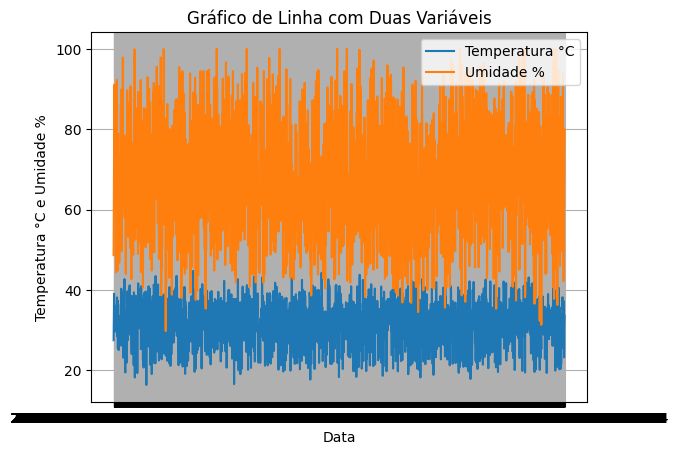

In [67]:
# Criação do gráfico
plt.plot(df_limpo["timestamp"], df_limpo["temperature_c"], label="Temperatura °C")
plt.plot(df_limpo["timestamp"], df_limpo["humidity_pct"], label="Umidade %")

# Personalização do gráfico
plt.xlabel("Data")
plt.ylabel("Temperatura °C e Umidade %")
plt.title("Gráfico de Linha com Duas Variáveis")
plt.legend()
plt.grid(True)

# Exibe o gráfico
plt.show()

In [68]:
# Correlação entre Temperatura e Umidade
df_perigo_umidade = df_limpo.loc[
    df_limpo["humidity_pct"] < 40, ["timestamp", "temperature_c", "humidity_pct"]
]
df_perigo_temperatura = df_limpo.loc[
    df_limpo["temperature_c"] > (df_limpo["temperature_c"].mean() + 5), ["timestamp", "temperature_c", "humidity_pct"]
]

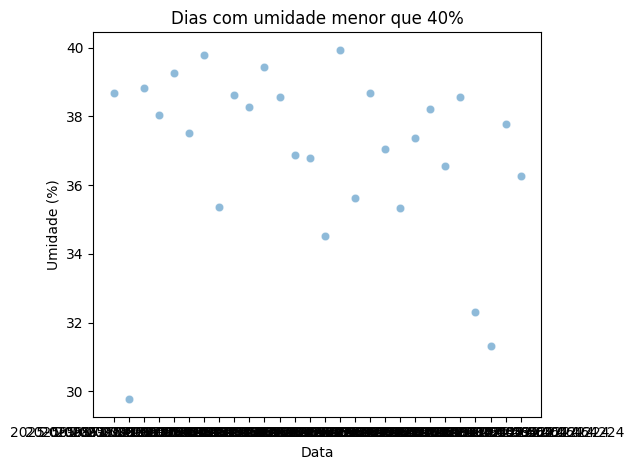

In [69]:
# Dias com umidade menor que 40%
plt.figure()
sns.scatterplot(data=df_perigo_umidade, x="timestamp", y="humidity_pct", alpha=0.5)
plt.title("Dias com umidade menor que 40%")
plt.xlabel("Data")
plt.ylabel("Umidade (%)")
plt.tight_layout()
plt.show()

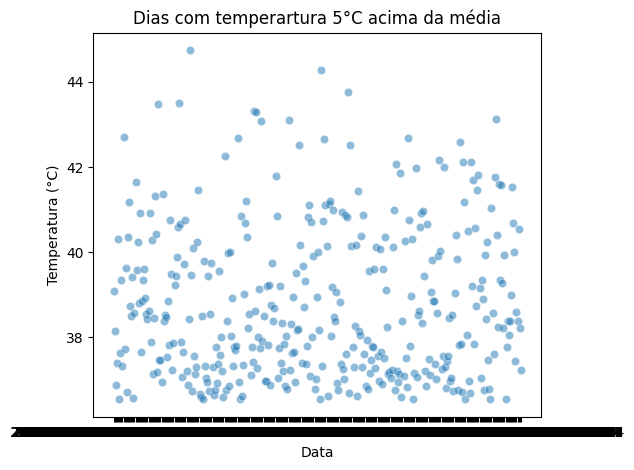

In [70]:
# Dias com temperatura 5° acima da média
plt.figure()
sns.scatterplot(data=df_perigo_temperatura, x="timestamp", y="temperature_c", alpha=0.5)
plt.title("Dias com temperartura 5°C acima da média")
plt.xlabel("Data")
plt.ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()

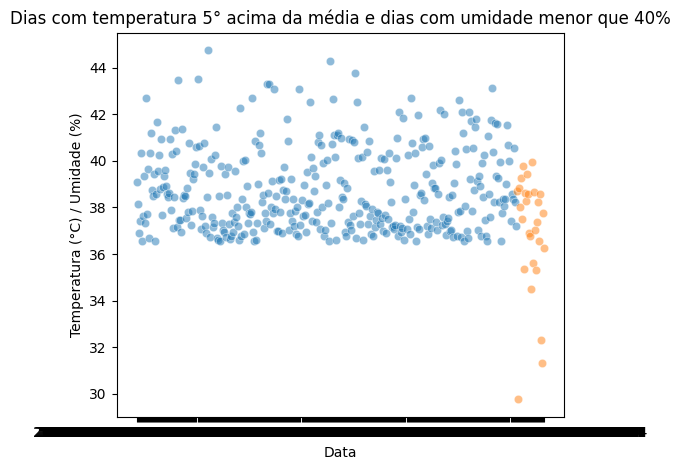

In [71]:
# Dias com temperatura 5° acima da média e dias com umidade menor que 40%
plt.figure()
sns.scatterplot(data=df_perigo_temperatura, x="timestamp", y="temperature_c", alpha=0.5)
sns.scatterplot(data=df_perigo_umidade, x="timestamp", y="humidity_pct", alpha=0.5)
plt.title("Dias com temperatura 5° acima da média e dias com umidade menor que 40%")
plt.xlabel("Data")
plt.ylabel("Temperatura (°C) / Umidade (%)")
plt.tight_layout()
plt.show()